In [25]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import glob 
import re 

In [26]:
def blockify_covariance(flat_cov, nsn):
    cov = np.zeros((nsn, nsn))
    idx = np.tril_indices(nsn)
    cov[idx] = flat_cov
    cov = cov + cov.T - np.diag(cov.diagonal())
    return cov
    

In [27]:
DES_PATH = '/home/shin101/Work/DES_analysis/DES-SN5YR'

des5yr = pd.read_csv(DES_PATH+'/4_DISTANCES_COVMAT/des_sn5yr.csv',sep='\s+',comment='#',header=0)
nsn = len(des5yr)
covmat = np.load(DES_PATH+'/4_DISTANCES_COVMAT/STAT+SYS.npz')['cov']
nsn_covmat = np.load(DES_PATH+'/4_DISTANCES_COVMAT/STAT+SYS.npz')['nsn']
assert nsn == nsn_covmat, f"Number of supernovae in metadata ({nsn}) does not match number in covariance matrix ({nsn_covmat})"
cov = bolckify_covariance(covmat, nsn)

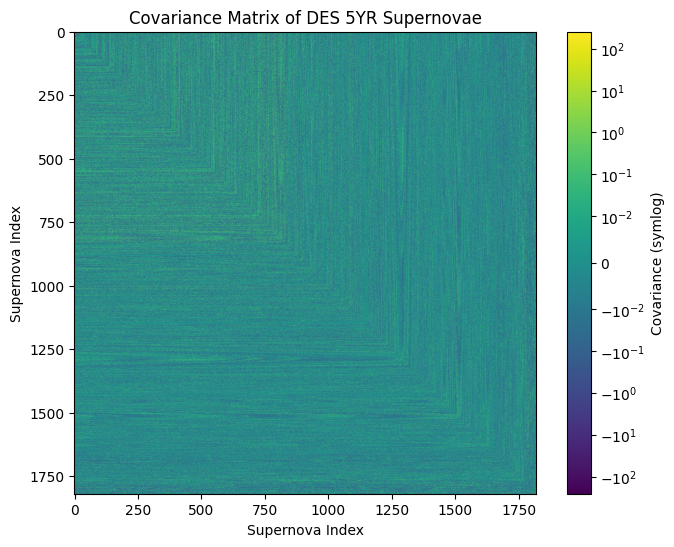

In [28]:

plt.figure(figsize=(8, 6))
plt.imshow(
    cov,
    cmap='viridis',
    norm=SymLogNorm(linthresh=1e-2, vmin=-np.max(np.abs(cov)), vmax=np.max(np.abs(cov)))
)
plt.colorbar(label='Covariance (symlog)')
plt.title('Covariance Matrix of DES 5YR Supernovae')
plt.xlabel('Supernova Index')
plt.ylabel('Supernova Index')
plt.show()

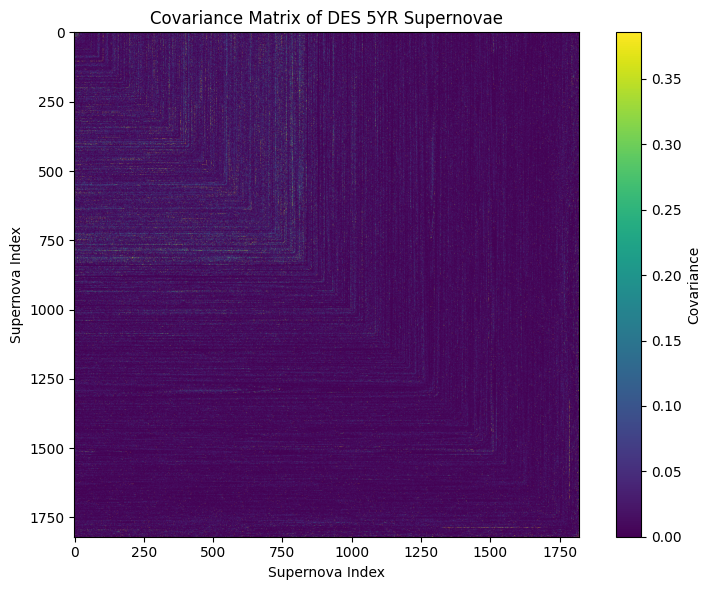

In [29]:

plt.figure(figsize=(8, 6))
plt.imshow(
    cov,
    cmap='viridis',
    vmin=-np.percentile(np.abs(cov), 0), 
    vmax=np.percentile(np.abs(cov), 99)
)
plt.colorbar(label='Covariance')
plt.title('Covariance Matrix of DES 5YR Supernovae')
plt.xlabel('Supernova Index')
plt.ylabel('Supernova Index')
plt.tight_layout()
plt.show()

In [30]:
cov_files = glob.glob(DES_PATH+'/4_DISTANCES_COVMAT/SingleSYS_CovMatrix/*.npz')
pec_vel_cov_flat = np.load(DES_PATH+ '/4_DISTANCES_COVMAT/SingleSYS_CovMatrix/VPEC.npz')
vpec_cov = blockify_covariance(pec_vel_cov_flat['cov'], nsn)

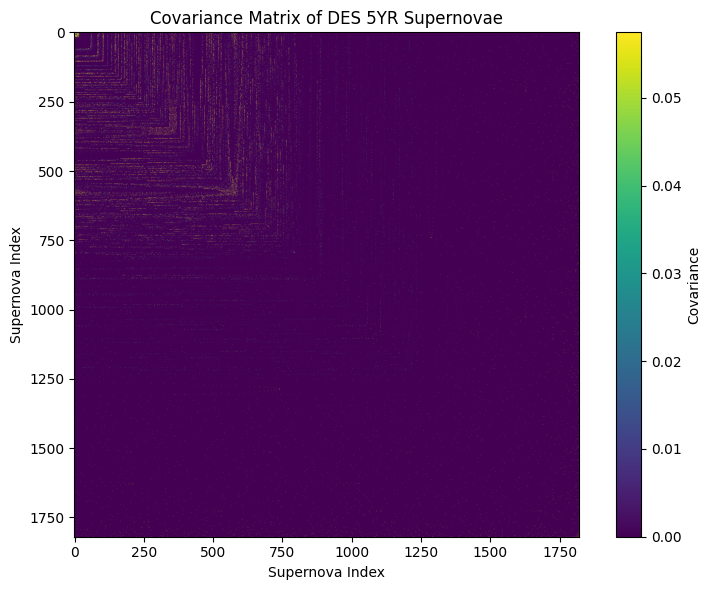

In [31]:

plt.figure(figsize=(8, 6))
plt.imshow(
    vpec_cov,
    cmap='viridis',
    vmin=-np.percentile(np.abs(vpec_cov), 0), 
    vmax=np.percentile(np.abs(vpec_cov), 99)
)
plt.colorbar(label='Covariance')
plt.title('Covariance Matrix of DES 5YR Supernovae')
plt.xlabel('Supernova Index')
plt.ylabel('Supernova Index')
plt.tight_layout()
plt.show()